In [1]:
pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import torch
import torchvision 
import torchvision.models.detection as models
from tqdm import tqdm
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection import fasterrcnn_resnet50_fpn

In [39]:
import os 
import numpy as np
import pandas as pd 
import torchvision 
import ast
import re
import cv2 
import seaborn as sns
from torchvision.ops import nms
from sklearn.metrics import auc
from PIL import Image, ImageDraw
from collections import Counter 
import matplotlib.pyplot as plt 
from tqdm import tqdm
from torchvision.ops import box_iou
from sklearn.metrics import precision_score, recall_score, f1_score
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T 
import torchvision.transforms as transforms
from torchvision.models.detection import FasterRCNN

In [4]:
# Hàm tạo mô hình Faster R-CNN
def get_model(num_classes):
    # Sử dụng Faster R-CNN với backbone ResNet50
    # model = models.fasterrcnn_resnet50_fpn(weights=models.FasterRCNN_ResNet50_FPN_Weights.COCO_V1)
    model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
    
    # Thay đổi đầu ra (head) để phù hợp với số lớp của bạn
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
    
    return model

# Khởi tạo mô hình
num_classes = 7  
model = get_model(num_classes)

In [7]:
checkpoint = torch.load("model_new/fasterrcnn_resnet50_fpn_epoch_5.pth", map_location='cpu')

C:\Users\HoangVan\AppData\Local\Temp\ipykernel_52548\931630962.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("model_new/fasterrcnn_resnet50_fpn

In [8]:
model.load_state_dict(checkpoint['model_state_dict'])

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

### Hàm đánh giá 

In [9]:
# Hàm tính IoU
def calculate_iou(box1, box2):
    x1, y1, x2, y2 = box1
    x1g, y1g, x2g, y2g = box2

    xi1, yi1 = max(x1, x1g), max(y1, y1g)
    xi2, yi2 = min(x2, x2g), min(y2, y2g)

    inter_area = max(0, xi2 - xi1) * max(0, yi1 - yi1)
    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (x2g - x1g) * (y2g - y1g)

    union_area = box1_area + box2_area - inter_area
    iou = inter_area / union_area if union_area != 0 else 0
    return iou

In [10]:
data_val = pd.read_csv(r"data\test_data.csv")

In [11]:
def convert_bbox(bbox_str): 
    return ast.literal_eval(bbox_str)

In [12]:
data_val['bbox'] = data_val['bbox'].apply(convert_bbox)
data_val['track_id'] = data_val['track_id'].apply(convert_bbox)
data_val['labels'] = data_val['labels'].apply(convert_bbox)

In [13]:
def convert_bbox(bbox):
    return [ [x, y, x + w, y + h] for x, y, w, h in bbox]

# Áp dụng hàm cho cột 'bbox'
data_val['bbox'] = data_val['bbox'].apply(convert_bbox)

In [14]:
label_mapping = {
    'DNoHelmet': 1,
    'DHelmet': 2,
    'DHelmetPHelmet': 3,
    'DHelmetPNoHelmet': 4,
    'DNoHelmetPHelmet': 5,
    'DNoHelmetPNoHelmet': 6
}

In [15]:
data_val['new_labels'] = data_val['new_labels'].apply(ast.literal_eval)

In [16]:
data_val['labels_map'] = data_val['new_labels'].apply(lambda labels: [label_mapping[label] for label in labels])

In [17]:
original_width, original_height = 1920, 1080
new_width, new_height = 512, 512

# Hàm điều chỉnh bounding box
def resize_bbox_list(bbox_list):
    resized_bboxes = []
    for bbox in bbox_list:
        xmin, ymin, xmax, ymax = bbox
        xmin_new = xmin / original_width * new_width
        ymin_new = ymin / original_height * new_height
        xmax_new = xmax / original_width * new_width
        ymax_new = ymax / original_height * new_height
        resized_bboxes.append([xmin_new, ymin_new, xmax_new, ymax_new])
    return resized_bboxes

data_val['bbox_new'] = data_val['bbox'].apply(resize_bbox_list)

In [18]:
data_val

,image_name,track_id,labels,bbox,image_path,new_labels,labels_map,bbox_new
0,Bago_highway_10_01,"[_qduigg0eu, _iajtqobrr, _y3rk2zkrs]","[DNoHelmet, DNoHelmet, DHelmetP1Helmet]","[[274.0, 686.0, 402.0, 883.0], [367.0, 676.0, ...",/kaggle/input/helmet-detection/test/Bago_highw...,"[DNoHelmet, DNoHelmet, DHelmetPHelmet]","[1, 1, 3]","[[73.06666666666666, 325.2148148148148, 107.2,..."
1,Bago_highway_10_02,"[_qduigg0eu, _iajtqobrr, _y3rk2zkrs]","[DNoHelmet, DNoHelmet, DHelmetP1Helmet]","[[274.0, 686.0, 402.0, 883.0], [367.0, 676.0, ...",/kaggle/input/helmet-detection/test/Bago_highw...,"[DNoHelmet, DNoHelmet, DHelmetPHelmet]","[1, 1, 3]","[[73.06666666666666, 325.2148148148148, 107.2,..."
2,Bago_highway_10_03,"[_qduigg0eu, _iajtqobrr, _y3rk2zkrs]","[DNoHelmet, DNoHelmet, DHelmetP1Helmet]","[[274.0, 686.0, 402.0, 883.0], [367.0, 676.0, ...",/kaggle/input/helmet-detection/test/Bago_highw...,"[DNoHelmet, DNoHelmet, DHelmetPHelmet]","[1, 1, 3]","[[73.06666666666666, 325.2148148148148, 107.2,..."
3,Bago_highway_10_04,"[_qduigg0eu, _iajtqobrr, _y3rk2zkrs]","[DNoHelmet, DNoHelmet, DHelmetP1Helmet]","[[274.0, 686.0, 402.0, 883.0], [367.0, 676.0, ...",/kaggle/input/helmet-detection/test/Bago_highw...,"[DNoHelmet, DNoHelmet, DHelmetPHelmet]","[1, 1, 3]","[[73.06666666666666, 325.2148148148148, 107.2,..."
4,Bago_highway_10_05,"[_qduigg0eu, _iajtqobrr]","[DNoHelmet, DNoHelmet]","[[274.0, 686.0, 402.0, 883.0], [367.0, 676.0, ...",/kaggle/input/helmet-detection/test/Bago_highw...,"[DNoHelmet, DNoHelmet]","[1, 1]","[[73.06666666666666, 325.2148148148148, 107.2,..."
...,...,...,...,...,...,...,...,...
18195,Yangon_II_6_95,"[_demv0qukm, _n25027n7x, _r5oid9gr1, _tge3o4kcp]","[DNoHelmet, DNoHelmetP0NoHelmetP1NoHelmet, DNo...","[[599.0, 666.0, 751.0, 890.0], [687.0, 666.0, ...",/kaggle/input/helmet-detection/test/Yangon_II_...,"[DNoHelmet, DNoHelmetPNoHelmet, DNoHelmet, DHe...","[1, 6, 1, 2]","[[159.73333333333332, 315.73333333333335, 200...."
18196,Yangon_II_6_96,"[_demv0qukm, _n25027n7x, _r5oid9gr1, _tge3o4kcp]","[DNoHelmet, DNoHelmetP0NoHelmetP1NoHelmet, DNo...","[[614.0, 665.0, 769.0, 892.0], [694.0, 667.0, ...",/kaggle/input/helmet-detection/test/Yangon_II_...,"[DNoHelmet, DNoHelmetPNoHelmet, DNoHelmet, DHe...","[1, 6, 1, 2]","[[163.73333333333332, 315.25925925925924, 205...."
18197,Yangon_II_6_97,"[_demv0qukm, _n25027n7x, _r5oid9gr1, _tge3o4kcp]","[DNoHelmet, DNoHelmetP0NoHelmetP1NoHelmet, DNo...","[[629.0, 663.0, 786.0, 893.0], [705.0, 667.0, ...",/kaggle/input/helmet-detection/test/Yangon_II_...,"[DNoHelmet, DNoHelmetPNoHelmet, DNoHelmet, DHe...","[1, 6, 1, 2]","[[167.73333333333332, 314.31111111111113, 209...."
18198,Yangon_II_6_98,"[_demv0qukm, _n25027n7x, _r5oid9gr1, _tge3o4kcp]","[DNoHelmet, DNoHelmetP0NoHelmetP1NoHelmet, DNo...","[[645.0, 662.0, 804.0, 895.0], [717.0, 667.0, ...",/kaggle/input/helmet-detection/test/Yangon_II_...,"[DNoHelmet, DNoHelmetPNoHelmet, DNoHelmet, DHe...","[1, 6, 1, 2]","[[172.0, 313.837037037037, 214.4, 424.29629629..."


In [20]:
data_val2 = data_val[:30]
data_val2.head()

,image_name,track_id,labels,bbox,image_path,new_labels,labels_map,bbox_new
0,Bago_highway_10_01,"[_qduigg0eu, _iajtqobrr, _y3rk2zkrs]","[DNoHelmet, DNoHelmet, DHelmetP1Helmet]","[[274.0, 686.0, 402.0, 883.0], [367.0, 676.0, ...",/kaggle/input/helmet-detection/test/Bago_highw...,"[DNoHelmet, DNoHelmet, DHelmetPHelmet]","[1, 1, 3]","[[73.06666666666666, 325.2148148148148, 107.2,..."
1,Bago_highway_10_02,"[_qduigg0eu, _iajtqobrr, _y3rk2zkrs]","[DNoHelmet, DNoHelmet, DHelmetP1Helmet]","[[274.0, 686.0, 402.0, 883.0], [367.0, 676.0, ...",/kaggle/input/helmet-detection/test/Bago_highw...,"[DNoHelmet, DNoHelmet, DHelmetPHelmet]","[1, 1, 3]","[[73.06666666666666, 325.2148148148148, 107.2,..."
2,Bago_highway_10_03,"[_qduigg0eu, _iajtqobrr, _y3rk2zkrs]","[DNoHelmet, DNoHelmet, DHelmetP1Helmet]","[[274.0, 686.0, 402.0, 883.0], [367.0, 676.0, ...",/kaggle/input/helmet-detection/test/Bago_highw...,"[DNoHelmet, DNoHelmet, DHelmetPHelmet]","[1, 1, 3]","[[73.06666666666666, 325.2148148148148, 107.2,..."
3,Bago_highway_10_04,"[_qduigg0eu, _iajtqobrr, _y3rk2zkrs]","[DNoHelmet, DNoHelmet, DHelmetP1Helmet]","[[274.0, 686.0, 402.0, 883.0], [367.0, 676.0, ...",/kaggle/input/helmet-detection/test/Bago_highw...,"[DNoHelmet, DNoHelmet, DHelmetPHelmet]","[1, 1, 3]","[[73.06666666666666, 325.2148148148148, 107.2,..."
4,Bago_highway_10_05,"[_qduigg0eu, _iajtqobrr]","[DNoHelmet, DNoHelmet]","[[274.0, 686.0, 402.0, 883.0], [367.0, 676.0, ...",/kaggle/input/helmet-detection/test/Bago_highw...,"[DNoHelmet, DNoHelmet]","[1, 1]","[[73.06666666666666, 325.2148148148148, 107.2,..."


In [19]:
class CustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe 
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row['image_path']
        image_name = row['image_name']
        
        image = Image.open(image_path).convert("RGB")

        track_ids = row['track_id'] 
        bboxes = row['bbox'] 

        boxes = torch.tensor(bboxes, dtype=torch.float32)
        if boxes.numel() == 0:
            boxes = boxes.view(0, 4)  # Đảm bảo có hình dạng (0, 4)
        labels = torch.tensor(row['labels_map'], dtype=torch.int64)
        
        target = {
            "boxes": boxes,
            "labels": labels
        }

        if self.transform:
            original_width, original_height = image.size
            
            image = self.transform(image)
            new_width, new_height = image.shape[1], image.shape[2]
            if (original_width != new_width or original_height != new_height):
                # Lấy kích thước mới của ảnh
                # print(original_width, original_height, new_width, new_height) 
                    
                # Tính tỷ lệ thay đổi kích thước cho các chiều
                width_ratio = new_width / original_width
                height_ratio = new_height / original_height

                boxes[:, 0] *= width_ratio 
                boxes[:, 1] *= height_ratio  
                boxes[:, 2] *= width_ratio 
                boxes[:, 3] *= height_ratio 

                target["boxes"] = boxes
        
        return image, target

In [21]:
transform = T.Compose([
    T.Resize((512, 512)),  
    T.ToTensor()       
])

dataset_val = CustomDataset(data_val, transform=transform)

In [22]:
val_loader = DataLoader(dataset_val, 
                        batch_size=8,                       
                        )

### Bật chế độ thử nghiệm model 

In [23]:
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [24]:
data_val.head()

,image_name,track_id,labels,bbox,image_path,new_labels,labels_map,bbox_new
0,Bago_highway_10_01,"[_qduigg0eu, _iajtqobrr, _y3rk2zkrs]","[DNoHelmet, DNoHelmet, DHelmetP1Helmet]","[[274.0, 686.0, 402.0, 883.0], [367.0, 676.0, ...",/kaggle/input/helmet-detection/test/Bago_highw...,"[DNoHelmet, DNoHelmet, DHelmetPHelmet]","[1, 1, 3]","[[73.06666666666666, 325.2148148148148, 107.2,..."
1,Bago_highway_10_02,"[_qduigg0eu, _iajtqobrr, _y3rk2zkrs]","[DNoHelmet, DNoHelmet, DHelmetP1Helmet]","[[274.0, 686.0, 402.0, 883.0], [367.0, 676.0, ...",/kaggle/input/helmet-detection/test/Bago_highw...,"[DNoHelmet, DNoHelmet, DHelmetPHelmet]","[1, 1, 3]","[[73.06666666666666, 325.2148148148148, 107.2,..."
2,Bago_highway_10_03,"[_qduigg0eu, _iajtqobrr, _y3rk2zkrs]","[DNoHelmet, DNoHelmet, DHelmetP1Helmet]","[[274.0, 686.0, 402.0, 883.0], [367.0, 676.0, ...",/kaggle/input/helmet-detection/test/Bago_highw...,"[DNoHelmet, DNoHelmet, DHelmetPHelmet]","[1, 1, 3]","[[73.06666666666666, 325.2148148148148, 107.2,..."
3,Bago_highway_10_04,"[_qduigg0eu, _iajtqobrr, _y3rk2zkrs]","[DNoHelmet, DNoHelmet, DHelmetP1Helmet]","[[274.0, 686.0, 402.0, 883.0], [367.0, 676.0, ...",/kaggle/input/helmet-detection/test/Bago_highw...,"[DNoHelmet, DNoHelmet, DHelmetPHelmet]","[1, 1, 3]","[[73.06666666666666, 325.2148148148148, 107.2,..."
4,Bago_highway_10_05,"[_qduigg0eu, _iajtqobrr]","[DNoHelmet, DNoHelmet]","[[274.0, 686.0, 402.0, 883.0], [367.0, 676.0, ...",/kaggle/input/helmet-detection/test/Bago_highw...,"[DNoHelmet, DNoHelmet]","[1, 1]","[[73.06666666666666, 325.2148148148148, 107.2,..."


In [25]:
label_mapping_2 = {
    1: 'DNoHelmet',
    2: 'DHelmet',
    3: 'DHelmetPHelmet',
    4: 'DHelmetPNoHelmet',
    5: 'DNoHelmetPHelmet',
    6: 'DNoHelmetPNoHelmet'
}

### Dự đoán ảnh

In [186]:
image_path = r"images_validation\ĐHQG\462567638_1518506118808867_1572388297611014738_n.jpg"
image = Image.open(image_path).convert("RGB")
image_tensor = transform(image).unsqueeze(0) 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_tensor = image_tensor.to(device)

with torch.no_grad(): 
    predictions = model(image_tensor)

In [187]:
predictions 

[{'boxes': tensor([[287.4187, 328.2326, 351.5038, 430.7948],
          [216.7907, 333.1754, 258.4908, 415.2354],
          [ 74.9606, 340.0120, 118.1622, 417.1004],
          [181.6279, 333.0253, 210.1761, 413.7664],
          [255.7929, 327.4027, 290.7632, 446.7103],
          [255.3618, 322.3853, 289.6143, 446.2848],
          [  1.9466, 340.6612,  38.5685, 421.2316],
          [182.0251, 333.0169, 209.5003, 414.6229],
          [ 24.4584, 335.5303,  87.9947, 422.9484],
          [ 76.2377, 341.4173, 120.0799, 417.9835],
          [388.9344, 339.6207, 443.2189, 429.9729],
          [181.1908, 338.5080, 208.7194, 413.8583],
          [214.1698, 331.3312, 340.1370, 433.4655],
          [256.0605, 321.1784, 289.3739, 447.3235]]),
  'labels': tensor([2, 2, 3, 3, 2, 3, 2, 2, 2, 2, 2, 4, 2, 4]),
  'scores': tensor([0.9613, 0.9241, 0.7400, 0.7299, 0.6739, 0.5483, 0.4560, 0.4167, 0.2926,
          0.1862, 0.1708, 0.1386, 0.0665, 0.0663])}]

In [188]:
predicted_boxes = predictions[0]['boxes'].cpu().numpy()
predicted_labels = predictions[0]['labels'].cpu().numpy()
predicted_scores = predictions[0]['scores'].cpu().numpy()

threshold = 0.5
filtered_indices = predicted_scores > threshold

filtered_boxes = predicted_boxes[filtered_indices]
filtered_labels = predicted_labels[filtered_indices]
filtered_scores = predicted_scores[filtered_indices]

for i in range(len(filtered_boxes)):
    print(f"Box: {filtered_boxes[i]}, Label: {filtered_labels[i]}, Score: {filtered_scores[i]}")

Box: [287.4187  328.23264 351.5038  430.79477], Label: 2, Score: 0.9613189697265625
Box: [216.7907  333.17535 258.49084 415.2354 ], Label: 2, Score: 0.9240686297416687
Box: [ 74.96059  340.012    118.162186 417.10043 ], Label: 3, Score: 0.739972710609436
Box: [181.62788 333.02527 210.17606 413.76636], Label: 3, Score: 0.7298846244812012
Box: [255.79292 327.40268 290.76315 446.71027], Label: 2, Score: 0.673949122428894
Box: [255.36177 322.3853  289.61432 446.28476], Label: 3, Score: 0.5482763648033142


In [189]:
predicted_boxes = predictions[0]['boxes'].cpu()
predicted_labels = predictions[0]['labels'].cpu()
predicted_scores = predictions[0]['scores'].cpu()

# Thiết lập ngưỡng confidence
threshold = 0.5
filtered_indices = predicted_scores > threshold

filtered_boxes = predicted_boxes[filtered_indices]
filtered_labels = predicted_labels[filtered_indices]
filtered_scores = predicted_scores[filtered_indices]

# Áp dụng NMS
iou_threshold = 0.5  # Ngưỡng IoU để loại bỏ các box dư thừa
nms_indices = nms(filtered_boxes, filtered_scores, iou_threshold)

# Lấy các box, label, score sau khi áp dụng NMS
filtered_boxes = filtered_boxes[nms_indices]
filtered_labels = filtered_labels[nms_indices]
filtered_scores = filtered_scores[nms_indices]

# In kết quả sau khi áp dụng NMS
for i in range(len(filtered_boxes)):
    print(f"Box: {filtered_boxes[i].numpy()}, Label: {filtered_labels[i].item()}, Score: {filtered_scores[i].item()}")
    


Box: [287.4187  328.23264 351.5038  430.79477], Label: 2, Score: 0.9613189697265625
Box: [216.7907  333.17535 258.49084 415.2354 ], Label: 2, Score: 0.9240686297416687
Box: [ 74.96059  340.012    118.162186 417.10043 ], Label: 3, Score: 0.739972710609436
Box: [181.62788 333.02527 210.17606 413.76636], Label: 3, Score: 0.7298846244812012
Box: [255.79292 327.40268 290.76315 446.71027], Label: 2, Score: 0.673949122428894


In [190]:
filtered_labels = filtered_labels.numpy()
type(filtered_labels)

numpy.ndarray

### Test ảnh trong bộ Test - Validation

In [191]:
# Đọc lại ảnh gốc với OpenCV
image_re = cv2.imread(image_path)
image_cv = cv2.cvtColor(image_re, cv2.COLOR_BGR2RGB)

original_height, original_width = image_cv.shape[:2]
resized_image = cv2.resize(image_cv, (512, 512))

scale_x = original_width / 512
scale_y = original_height / 512

for box, label in zip(filtered_boxes, filtered_labels):
    xmin, ymin, xmax, ymax = box
    label_text = label_mapping_2[label]
    cv2.rectangle(resized_image, 
                  (int(xmin), int(ymin)), 
                  (int(xmax), int(ymax)), 
                  (0, 255, 0), 2)
    # Thêm nhãn vào bounding box
    cv2.putText(resized_image, label_text, 
                (int(xmin), int(ymin) - 10),  # Vị trí phía trên box
                cv2.FONT_HERSHEY_SIMPLEX, 
                0.5, (255, 0, 0), 2)  # Màu chữ và độ dày

# Resize ảnh về lại kích thước ban đầu
resized_back_image = cv2.resize(resized_image, (original_width, original_height))

# Điều chỉnh bounding boxes về kích thước ban đầu
adjusted_image = image_cv.copy()  # Sao chép ảnh gốc để vẽ box lên
for box, label in zip(filtered_boxes, filtered_labels):
    xmin, ymin, xmax, ymax = box
    # Chỉnh tọa độ bounding boxes về kích thước gốc
    xmin_orig = int(xmin * scale_x)
    ymin_orig = int(ymin * scale_y)
    xmax_orig = int(xmax * scale_x)
    ymax_orig = int(ymax * scale_y)
    label_text = label_mapping_2[label]
    cv2.rectangle(adjusted_image, 
                  (xmin_orig, ymin_orig), 
                  (xmax_orig, ymax_orig), 
                  (0, 255, 0), 2)
    # Thêm nhãn vào bounding box
    cv2.putText(adjusted_image, label_text, 
                (xmin_orig, ymin_orig - 10),  # Vị trí phía trên box
                cv2.FONT_HERSHEY_SIMPLEX, 
                0.5, (255, 0, 0), 2)  # Màu chữ và độ dày

# Vẽ bounding box và nhãn trên ảnh gốc
image_with_boxes = image_cv.copy()

img = image_path.split("\\")[-1].split(".")[0]  # Tách theo đường dẫn và phần mở rộng
bboxes = data_val.loc[data_val['image_name'] == img, 'bbox'].values[0]
labels = data_val.loc[data_val['image_name'] == img, 'new_labels'].values[0]

for box, label in zip(bboxes, labels):
    xmin, ymin, xmax, ymax = box
    # Chỉnh lại tọa độ về kích thước gốc
    xmin_orig = int(xmin)
    ymin_orig = int(ymin)
    xmax_orig = int(xmax)
    ymax_orig = int(ymax)
    label_text = label
    cv2.rectangle(image_with_boxes,
                  (xmin_orig, ymin_orig),
                  (xmax_orig, ymax_orig),
                  (255, 0, 0), 2)  # Màu đỏ cho bounding box
    cv2.putText(image_with_boxes, label_text,
                (xmin_orig, ymin_orig - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (0, 255, 0), 2)  # Màu xanh lá cho nhãn


# Hiển thị ảnh đã resize về lại kích thước gốc
plt.figure(figsize = (16, 8))

plt.subplot(1, 2, 1)
plt.imshow(adjusted_image)
plt.axis("off")
plt.title("Image with Predicted Boxes")

plt.subplot(1, 2, 2)
plt.imshow(image_with_boxes)
plt.axis("off")
plt.title("Original Image with Bounding Boxes")

plt.tight_layout()
plt.show()

error: OpenCV(4.9.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:196: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


### Test trên ảnh thực tế

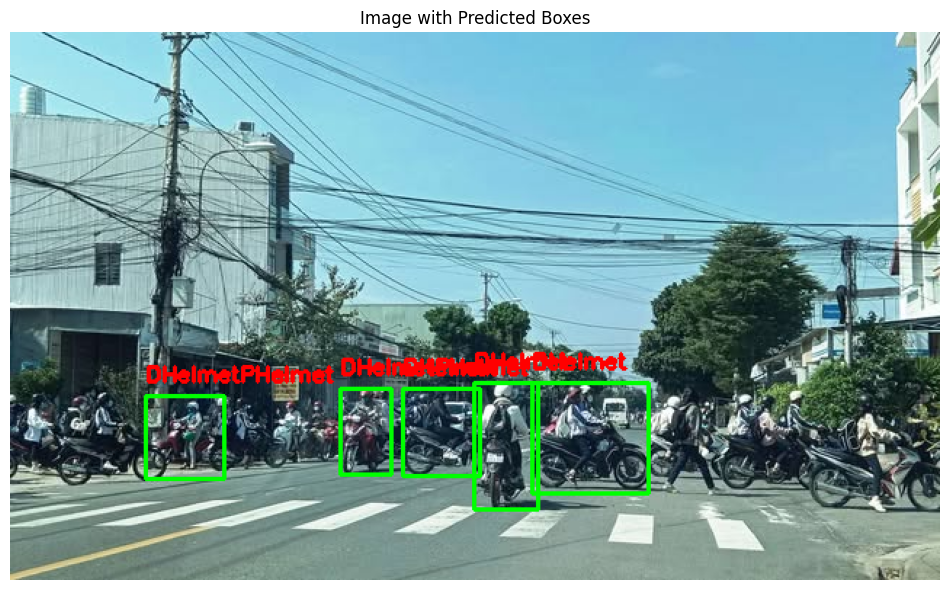

In [192]:
img_PIL = Image.open(image_path)
image_cv = img_PIL.convert("RGB")
image_cv = np.array(image_cv)

original_height, original_width = image_cv.shape[:2]
resized_image = cv2.resize(image_cv, (512, 512))

scale_x = original_width / 512
scale_y = original_height / 512

for box, label in zip(filtered_boxes, filtered_labels):
    xmin, ymin, xmax, ymax = box
    label_text = label_mapping_2[label]
    cv2.rectangle(resized_image, 
                  (int(xmin), int(ymin)), 
                  (int(xmax), int(ymax)), 
                  (0, 255, 0), 2)

    cv2.putText(resized_image, label_text, 
                (int(xmin), int(ymin) - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 
                0.5, (255, 0, 0), 2) 

resized_back_image = cv2.resize(resized_image, (original_width, original_height))

# Điều chỉnh bounding boxes về kích thước ban đầu
adjusted_image = image_cv.copy()
for box, label in zip(filtered_boxes, filtered_labels):
    xmin, ymin, xmax, ymax = box
    
    xmin_orig = int(xmin * scale_x)
    ymin_orig = int(ymin * scale_y)
    xmax_orig = int(xmax * scale_x)
    ymax_orig = int(ymax * scale_y)
    label_text = label_mapping_2[label]
    cv2.rectangle(adjusted_image, 
                  (xmin_orig, ymin_orig), 
                  (xmax_orig, ymax_orig), 
                  (0, 255, 0), 2)
   
    cv2.putText(adjusted_image, label_text, 
                (xmin_orig, ymin_orig - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 
                0.5, (255, 0, 0), 2)  

plt.figure(figsize = (12,6))

plt.imshow(adjusted_image)
plt.axis("off")
plt.title("Image with Predicted Boxes")

plt.tight_layout()
plt.show()

### Hàm tính mAP - IoU - Precision - Recall 

In [108]:
data_val_test = data_val[:50]

In [27]:
label_indices = range(1,7)

label_counts_df = pd.DataFrame({
    'label_index': label_indices,
    'label_name': [key for key, value in sorted(label_mapping.items(), key=lambda x: x[1])],  
    'Count': 0  
})

all_labels = [label for labels in data_val["labels_map"] for label in labels]
label_counts = Counter(all_labels)

# Gán giá trị đếm được cho cột Count dựa trên label_index
for label_index, count in label_counts.items():
    label_counts_df.loc[label_counts_df['label_index'] == label_index, 'Count'] = count

print(label_counts_df)

   label_index          label_name  Count
0            1           DNoHelmet   9971
1            2             DHelmet  22159
2            3      DHelmetPHelmet  11555
3            4    DHelmetPNoHelmet   3654
4            5    DNoHelmetPHelmet    446
5            6  DNoHelmetPNoHelmet   6744


In [28]:
dir = 'images'

# Ngưỡng IoU
iou_threshold = 0.5
all_predictions = []
# Lưu kết quả cho tất cả lớp
all_tp = {cls: 0 for cls in range(num_classes)}
all_fp = {cls: 0 for cls in range(num_classes)}
all_fn = {cls: 0 for cls in range(num_classes)}

class_dataframes = {cls: pd.DataFrame(columns=['cof', 'TP', 'FP']) for cls in range(num_classes)}

for i in tqdm(range(data_val.shape[0]), desc="Processing Images"):
    row = data_val.iloc[i]
    image_path = os.path.join(dir, f"{row['image_name']}.jpg")
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0) 

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    image_tensor = image_tensor.to(device)

    with torch.no_grad():  # Tắt tính toán gradient
        predictions = model(image_tensor)
    
    all_predictions.append(predictions)
                
    pred = predictions[0]
    ground_truths = {
        'labels': torch.tensor(row['labels_map']),  # Nhãn các đối tượng
        'boxes': torch.tensor(row['bbox_new']),   # Bounding boxes
    }
    
    pred_boxes = pred['boxes']
    pred_labels = pred['labels']
    pred_scores = pred['scores']
    
    gt_boxes = ground_truths['boxes']
    gt_labels = ground_truths['labels']
    
    for cls in range(1, 7):
        # Lọc theo class
        pred_cls_boxes = pred_boxes[pred_labels == cls]
        gt_cls_boxes = gt_boxes[gt_labels == cls]
        
        if len(pred_cls_boxes) == 0 and len(gt_cls_boxes) == 0:
            continue
        
        if len(gt_cls_boxes) == 0:
            # Không có ground truth cho class hiện tại
            all_fp[cls] += len(pred_cls_boxes)  # Tất cả dự đoán là False Positive
            continue

        device = pred_cls_boxes.device
        gt_cls_boxes = gt_cls_boxes.to(device)
        
        # Tính IoU
        iou_matrix = box_iou(pred_cls_boxes, gt_cls_boxes)
        
        matched_gt = set()
        for i in range(len(pred_cls_boxes)):
            max_iou, max_idx = iou_matrix[i].max(dim=0)
            if max_iou >= iou_threshold and max_idx.item() not in matched_gt:
                # TP
                all_tp[cls] += 1
                matched_gt.add(max_idx.item())
                class_dataframes[cls].loc[len(class_dataframes[cls])] = {
                    'cof': pred_scores[i].item(), 
                    'TP': 1, 
                    'FP': 0
                }
            else:
                # FP
                all_fp[cls] += 1
                class_dataframes[cls].loc[len(class_dataframes[cls])] = {
                    'cof': pred_scores[i].item(), 
                    'TP': 0, 
                    'FP': 1
                }
        
        # FN
        all_fn[cls] += len(gt_cls_boxes) - len(matched_gt)

Processing Images:   0%|          | 0/18200 [00:00<?, ?it/s]

Processing Images: 100%|██████████| 18200/18200 [12:26:38<00:00,  2.46s/it]     


In [37]:
for i in range(1, num_classes) : 
    class_dataframes[i] = class_dataframes[i].sort_values(by='cof', ascending = False)
    cumulative_tp = 0
    cumulative_fp = 0

    all_labels_of_class = label_counts_df.loc[label_counts_df['label_index'] == i, 'Count'].values[0]
    
    for idx, row in class_dataframes[i].iterrows():
        cumulative_tp += row['TP']
        cumulative_fp += row['FP']
        
        precision = cumulative_tp / (cumulative_tp + cumulative_fp) if (cumulative_tp + cumulative_fp) > 0 else 0
        
        recall = cumulative_tp / all_labels_of_class
        
        # Thêm các cột Precision và Recall vào DataFrame
        class_dataframes[i].at[idx, 'Precision'] = precision
        class_dataframes[i].at[idx, 'Recall'] = recall

In [115]:
class_dataframes[5] #.iloc[10:50]

,cof,TP,FP,Precision,Recall
87,0.997803,1,0,1.000000,0.002242
76,0.997409,1,0,1.000000,0.004484
97,0.997090,0,1,0.666667,0.004484
75,0.997013,1,0,0.750000,0.006726
80,0.996931,1,0,0.800000,0.008969
...,...,...,...,...,...
171,0.493677,1,0,0.615819,0.488789
141,0.486608,1,0,0.616901,0.491031
124,0.461861,0,1,0.615169,0.491031
172,0.454086,1,0,0.616246,0.493274


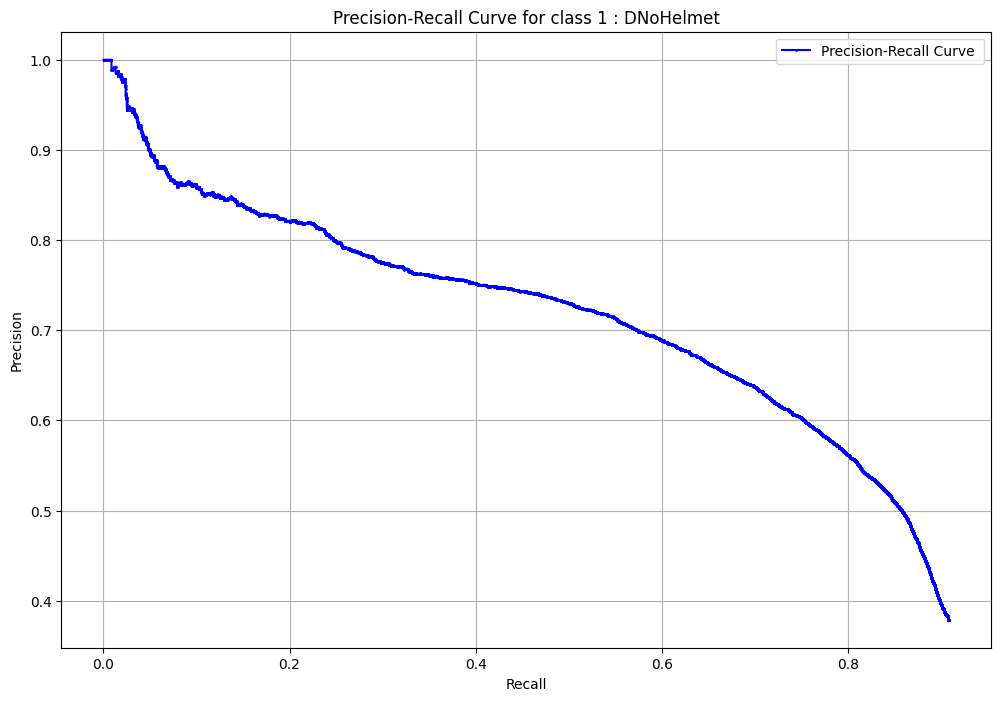

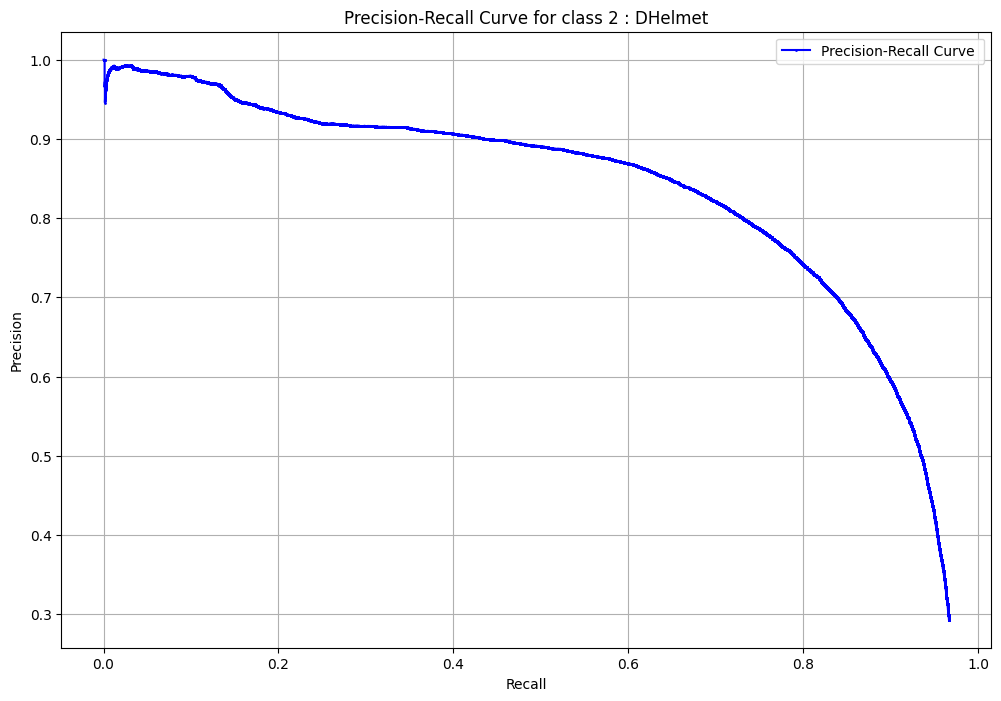

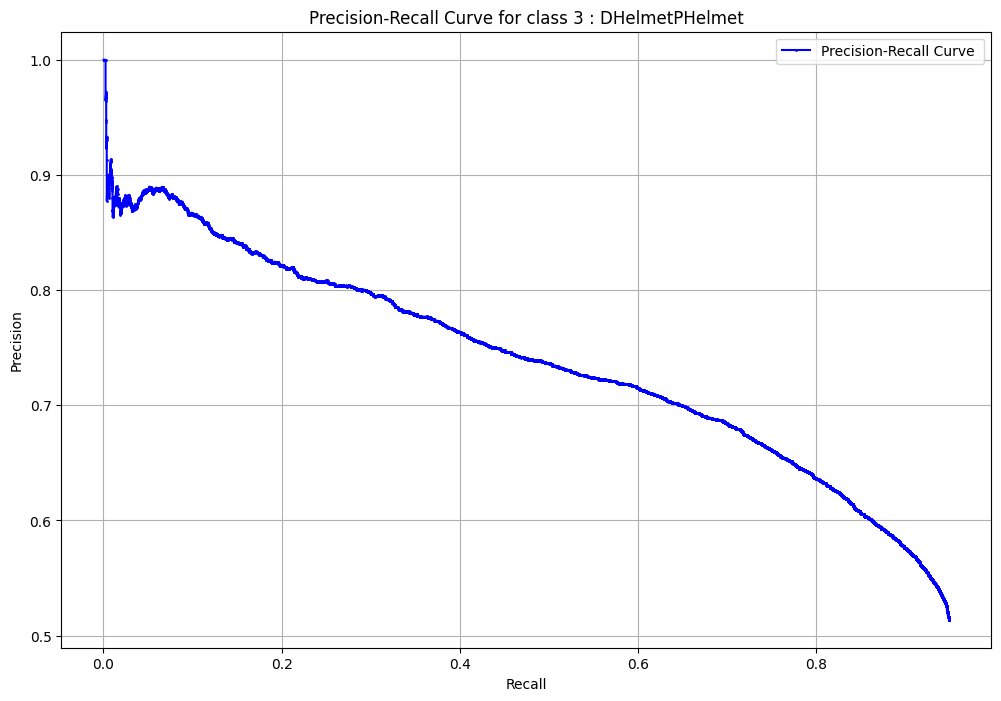

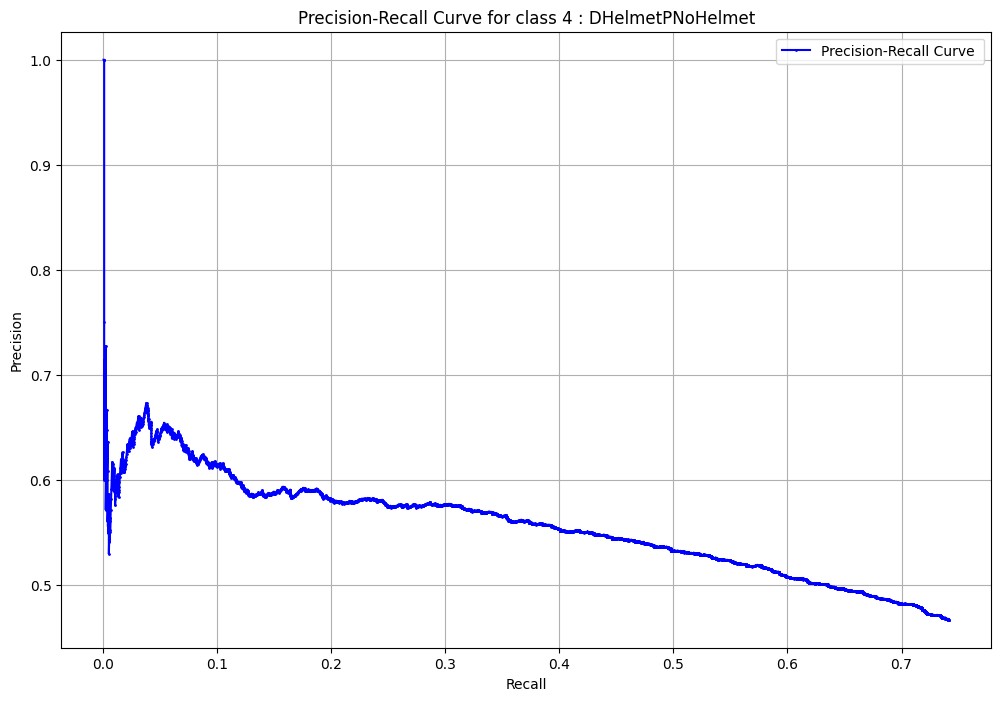

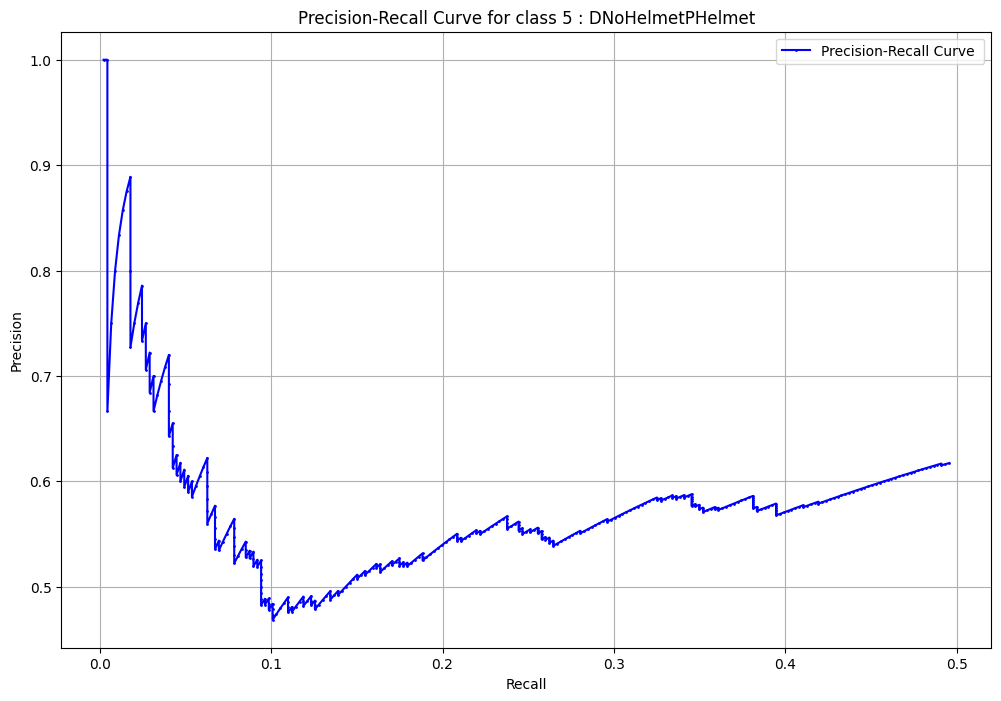

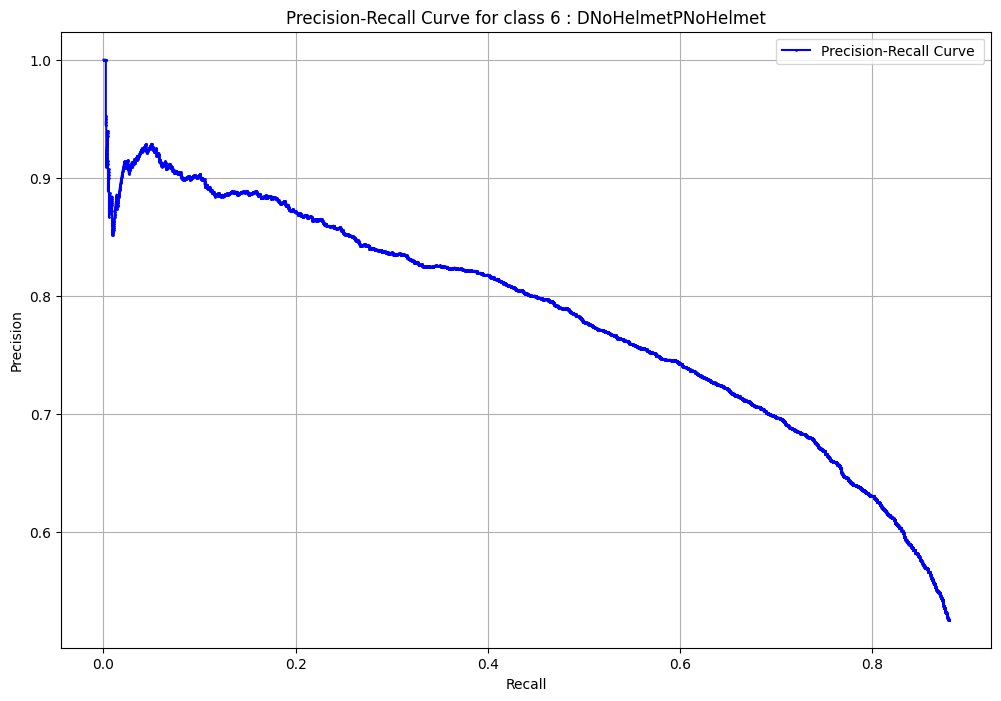

In [48]:
all_ap = []
for i in range(1, 7) :
    if(label_counts_df.loc[label_counts_df['label_index'] == i, 'Count'].values[0] == 0):
        continue
    name_class = label_mapping_2[i]
    pre = []
    rec = []

    for index, row in class_dataframes[i].iterrows():
        pre.append(row['Precision'])
        rec.append(row['Recall'])
    
    ap = auc(rec, pre) 
    all_ap.append(ap)
    
    # Vẽ biểu đồ
    plt.figure(figsize=(12, 8))
    plt.plot(rec, pre, marker='o', color='b', linestyle='-', label= f'Precision-Recall Curve ', markersize=1)
    plt.title(f'Precision-Recall Curve for class {i} : {name_class}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.grid(True)
    plt.legend()
    plt.show()

## AP and mAP50

In [193]:
all_ap

NameError: name 'all_ap' is not defined

In [59]:
mAP_test = sum(all_ap) / (num_classes-1)
mAP_test

0.5935701648623385

In [69]:
metrics = []

for i in range(1,num_classes): 
    df = class_dataframes[i] 
    filtered_df = df[df['cof'] >= 0.5]
    
    # Tính tổng TP và FP
    total_tp = filtered_df['TP'].sum()
    total_fp = filtered_df['FP'].sum()
    
    gt = label_counts_df.loc[label_counts_df['label_index'] == i, 'Count'].values[0]
    
    # Tính precision
    if total_tp + total_fp > 0:
        precision = total_tp / (total_tp + total_fp)
    else:
        precision = 0  # Nếu không có dự đoán nào
    
    # Tính recall
    if gt > 0:
        recall = total_tp / gt
    else:
        recall = 0  # Tránh chia cho 0
    
    # Lưu kết quả vào danh sách
    metrics.append((f"Class {i}", precision, recall))

# In kết quả
for cls, prec, rec in metrics:
    print(f"{cls}: Precision = {prec:.2f}, Recall = {rec:.2f}")


Class 1: Precision = 0.46, Recall = 0.88
Class 2: Precision = 0.46, Recall = 0.94
Class 3: Precision = 0.53, Recall = 0.94
Class 4: Precision = 0.47, Recall = 0.73
Class 5: Precision = 0.61, Recall = 0.48
Class 6: Precision = 0.54, Recall = 0.87


## Precision and Recall 

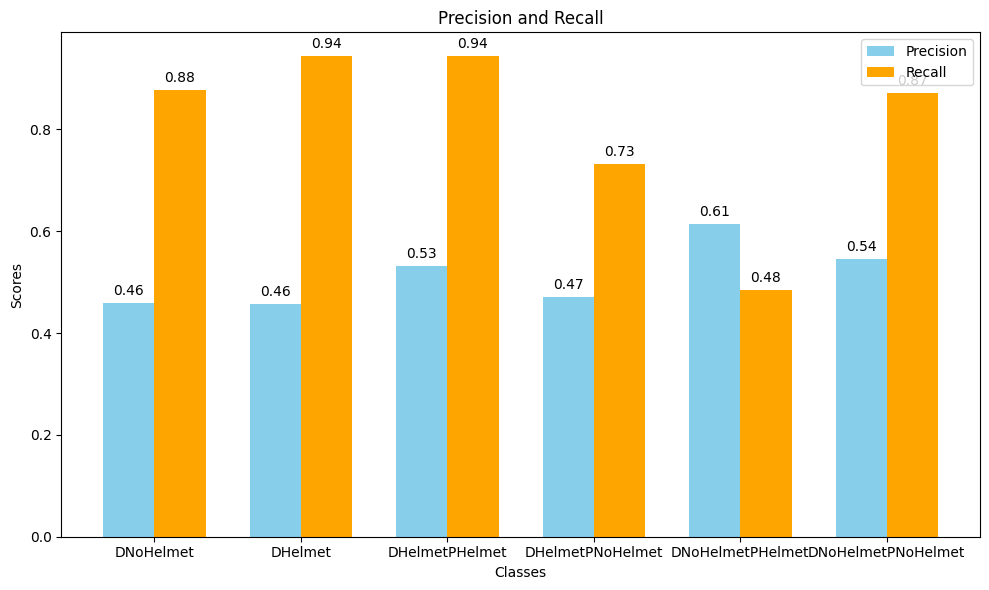

In [72]:
# Dữ liệu từ metrics
classes = ['DNoHelmet','DHelmet','DHelmetPHelmet','DHelmetPNoHelmet','DNoHelmetPHelmet','DNoHelmetPNoHelmet']
precisions = [prec for _, prec, _ in metrics]
recalls = [rec for _, _, rec in metrics]

# Vị trí các cột trên trục x
x = np.arange(len(classes))

# Chiều rộng của mỗi cột
width = 0.35

# Tạo biểu đồ
fig, ax = plt.subplots(figsize=(10, 6))

# Vẽ các cột Precision
rects1 = ax.bar(x - width/2, precisions, width, label='Precision', color='skyblue')

# Vẽ các cột Recall
rects2 = ax.bar(x + width/2, recalls, width, label='Recall', color='orange')

# Thêm nhãn, tiêu đề và chú thích
ax.set_xlabel('Classes')
ax.set_ylabel('Scores')
ax.set_title('Precision and Recall')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

# Hiển thị giá trị trên đỉnh mỗi cột
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.text(
            rect.get_x() + rect.get_width() / 2., height + 0.01,
            f'{height:.2f}', ha='center', va='bottom'
        )

add_labels(rects1)
add_labels(rects2)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

In [29]:
all_predictions[0][0]

{'boxes': tensor([[ 99.6106, 319.9880, 144.2385, 418.0865],
         [ 72.6996, 325.0902, 107.6556, 421.7733],
         [474.9700, 279.1479, 501.6001, 349.2805],
         [475.0297, 279.2475, 501.7295, 349.7010],
         [475.5631, 279.1032, 501.1870, 349.5770],
         [475.4349, 279.3057, 500.7135, 349.6059],
         [476.6120, 279.1378, 500.6509, 346.2102]]),
 'labels': tensor([1, 1, 3, 4, 5, 6, 2]),
 'scores': tensor([0.9977, 0.9966, 0.4434, 0.4097, 0.1860, 0.1770, 0.0577])}

## Confusion Matrix 

In [118]:
def update_confusion_matrix(confusion_matrix, pred_boxes, pred_labels, pred_scores, gt_boxes, gt_labels, iou_threshold = 0.5):
    for j, gt_box in enumerate(gt_boxes):
        gt_label = gt_labels[j]
        best_iou = 0
        best_pred_label = -1
        
        for i, pred_box in enumerate(pred_boxes):
            pred_label = pred_labels[i]
            pred_score = pred_scores[i]
            pred_box_list = pred_box.tolist()
            if pred_score >= 0.5:
                iou = calculate_iou(pred_box_list, gt_box)
  
                # Nếu IoU đủ lớn (>= threshold) và IoU lớn nhất so với các dự đoán trước đó
                if iou > best_iou and iou >= iou_threshold:
                    best_iou = iou
                    best_pred_label = pred_label
        
        # Nếu có bounding box dự đoán đủ mạnh (IoU > threshold), cập nhật confusion matrix
        if best_iou >= iou_threshold:
            if best_pred_label == gt_label:
                # Nếu nhãn giống nhau, cập nhật vào off-diagonal (không phải TP)
                confusion_matrix[gt_label-1][best_pred_label-1] += 1

            else:
                confusion_matrix[gt_label-1][best_pred_label-1] += 1
    return confusion_matrix


In [105]:
def calculate_iou(box1, box2):
    x1, y1, x2, y2 = box1
    x1g, y1g, x2g, y2g = box2

    # Tính toạ độ của điểm giao nhau
    xi1, yi1 = max(x1, x1g), max(y1, y1g)
    xi2, yi2 = min(x2, x2g), min(y2, y2g)

    # Tính diện tích giao nhau
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)

    # Tính diện tích của mỗi box
    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (x2g - x1g) * (y2g - y1g)

    # Tính diện tích liên hợp (union)
    union_area = box1_area + box2_area - inter_area

    # Tính IoU
    iou = inter_area / union_area if union_area != 0 else 0
    return iou


In [119]:
num_classes = 6  # Ví dụ: có 6 lớp
confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)

for i in tqdm(range(data_val.shape[0]), desc="Processing Images"):
    row = data_val.iloc[i]
    
    gt_boxes = row['bbox_new'] 
    gt_labels = row['labels_map'] 
    
    pred = all_predictions[i][0]
    pred_boxes = pred['boxes'].cpu().numpy() 
    pred_labels = pred['labels'].cpu().numpy()  
    pred_scores = pred['scores'].cpu().numpy() 

    confusion_matrix = update_confusion_matrix(confusion_matrix, pred_boxes, pred_labels, pred_scores, gt_boxes, gt_labels)

print("Confusion Matrix:")
print(confusion_matrix)

Processing Images: 100%|██████████| 18200/18200 [00:04<00:00, 3671.18it/s]

Confusion Matrix:
[[ 6479  2236    84     9     0   164]
 [  377 20162   197    16     0    29]
 [   40  3115  7496   218     0    85]
 [   49   998  1218   695     0   321]
 [    7   151   120    44     0    75]
 [  933   652   169   311     0  3999]]


## Heatmap Confusion matrix

In [126]:
label_mapping_3 = {
    0: 'DNoHelmet',
    1: 'DHelmet',
    2: 'DHelmetPHelmet',
    3: 'DHelmetPNoHelmet',
    4: 'DNoHelmetPHelmet',
    5: 'DNoHelmetPNoHelmet'
}

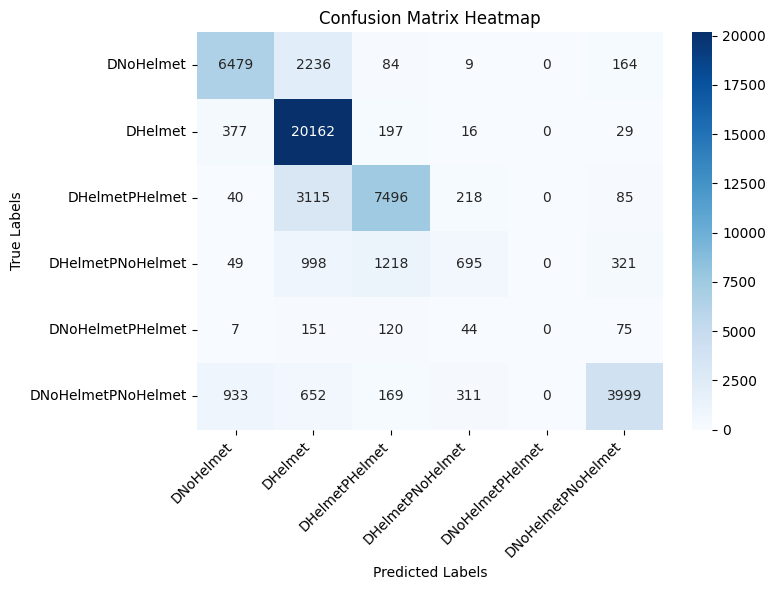

In [125]:
# Vẽ heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[label_mapping_3[i] for i in range(len(label_mapping_2))],
            yticklabels=[label_mapping_3[i] for i in range(len(label_mapping_2))],
            cbar=True)

# Thêm tiêu đề và nhãn cho các trục
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Hiển thị biểu đồ
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

In [6]:
import matplotlib.pyplot as plt 
import seaborn as sns 
normalized_matrix = [[0.2, 0.3, 0.5, 0.6, 0.7, 0.8],
                     [0.2, 0.3, 0.5, 0.6, 0.7, 0.8],
                     [0.2, 0.3, 0.5, 0.6, 0.7, 0.8],
                     [0.2, 0.3, 0.5, 0.6, 0.7, 0.8],
                     [0.2, 0.3, 0.5, 0.6, 0.7, 0.8],
                     [0.2, 0.3, 0.5, 0.6, 0.7, 0.8]
                    ]

In [2]:
label_mapping_3 = {
    0: 'DNoHelmet',
    1: 'DHelmet',
    2: 'DHelmetPHelmet',
    3: 'DHelmetPNoHelmet',
    4: 'DNoHelmetPHelmet',
    5: 'DNoHelmetPNoHelmet',
}

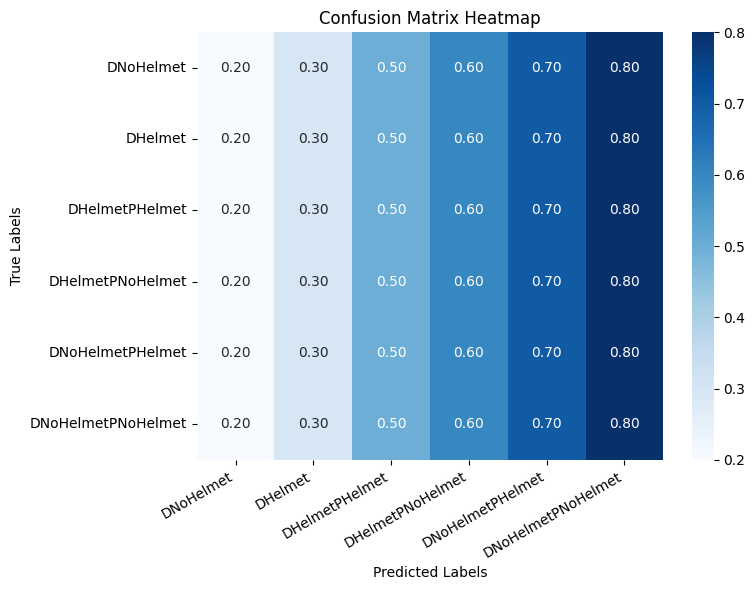

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(normalized_matrix, annot=True, fmt='0.2f', cmap='Blues', 
            yticklabels=[label_mapping_3[i] for i in range(6)],
            xticklabels=[label_mapping_3[i] for i in range(6)],
            cbar=True)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()